## XML-Annotationen in YOLO-Format umwandeln

In [1]:
# https://www.kaggle.com/code/ganjerlawrence/xml-annotations-to-yolo-format-and-visualization
import os
import xml.etree.ElementTree as ET
import cv2


def extract_word_bounds(word):
    """Extrahiert Bounding Box eines Wortes aus seinen Komponenten."""
    components = word.findall('cmp')

    if not components: # Weil einige Wörter kein CMP haben
        return None

    x_coor = []
    y_coor = []

    for cmp in components:
        x = int(cmp.get('x'))
        y = int(cmp.get('y'))
        width = int(cmp.get('width'))
        height = int(cmp.get('height'))

        x_coor.extend([x, x + width])
        y_coor.extend([y, y + height])

    return {'x_min': min(x_coor),'y_min': min(y_coor),'x_max': max(x_coor),'y_max': max(y_coor)}

## Alle oberen und unteren Punkte aller Wörter einer Zeile sammeln, um ein Polygon zu erstellen:
- obere Punkte: (x_min, y_min) und (x_max, y_min)
- untere Punkte: (x_min, y_max) und (x_max, y_max)
- diese Punkte werden dann sortiert und zu einem geschlossenen Polygon verbunden, das die gesamte Zeile umschließt.

In [2]:
def get_all_poly_coords(line):
    """Sammelt obere und untere Punkte aller Wörter einer Zeile."""
    top_points = []
    bottom_points = []

    for word in line.findall('word'):
        bounds = extract_word_bounds(word)

        if bounds:
            top_points.append((bounds['x_min'], bounds['y_min'])) #Oben links
            top_points.append((bounds['x_max'], bounds['y_min'])) #Oben rechts
            bottom_points.append((bounds['x_min'], bounds['y_max'])) # Unten ""
            bottom_points.append((bounds['x_max'], bounds['y_max']))


    return top_points, bottom_points

## Polygon erstellen:
- Sortierung der Punkte ist wichtig, damit das Polygon konsistent entweder im Uhrzeigersinn oder gegen den Uhrzeigersinn erstellt wird, da YOLO eine konsistente Reihenfolge erwartet.
- Die oberen Punkte werden von links nach rechts sortiert, die unteren Punkte von rechts nach links, um sicherzustellen, dass das Polygon korrekt geschlossen wird.
- Die Funktion verbindet dann die sortierten Punkte zu einem einizgen Polygon, das die gesamte Zeile umschließt.


In [3]:
def create_polygon(top_points, bottom_points):
    """Erstellt geschlossenes Polygon aus oberen und unteren Punkten."""
    # Sortieren
    top_points.sort(key=lambda p: p[0]) #p[0] nach x-Koordinate sortieren
    bottom_points.sort(key=lambda p: p[0], reverse=True) # Hier von rechts nach links

    return top_points + bottom_points #beide Listen verbinden

In [4]:
def create_polygon_no_sort(top_points, bottom_points):
    """Erstellt geschlossenes Polygon aus oberen und unteren Punkten ohne Sortierung."""
    return top_points + bottom_points

## Hauptfunktion: XML-Dateien durchgehen, Polygon-Koordinaten extrahieren, normalisieren und im YOLO-Format speichern:

In [5]:
#https://www.kaggle.com/code/ganjerlawrence/xml-annotations-to-yolo-format-and-visualization
def final_xml_to_yolo(xml_files, images_dir, output_dir):

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for xml_file in xml_files:

        tree = ET.parse(xml_file)
        root = tree.getroot()

        form_id = root.attrib['id']       # z.B. 0a01-000u
        image_path = os.path.join(images_dir, form_id + ".png")

        img = cv2.imread(image_path)
        H, W, _ = img.shape

        yolo_lines = []

        # finde alle Textzeilen
        line_elements = root.findall('.//handwritten-part/line')

        for line in line_elements:
            top_points, bottom_points = get_all_poly_coords(line)
            polygon = create_polygon(top_points, bottom_points)
            #polygon = create_polygon_no_sort(top_points, bottom_points)

            # YOLO: normalize polygon
            normalized = []
            for x, y in polygon:
                nx = x / W
                ny = y / H
                normalized.append(f"{nx} {ny}")

            #Klassen-ID 0 für Textzeile, gefolgt von den normalisierten Polygon-Koordinaten
            yolo_line = "0 " + " ".join(normalized)
            yolo_lines.append(yolo_line)

        out_file = os.path.join(output_dir, form_id + ".txt")
        with open(out_file, "w") as f:
            for line in yolo_lines:
                f.write(line + "\n")

In [6]:
xml_dir = "xml"
images_dir = "iam_yolo_dataset/images"
output_dir = "labels_no_sort"

xml_files = [os.path.join(xml_dir, f) for f in os.listdir(xml_dir) if f.endswith(".xml")]

final_xml_to_yolo(xml_files, images_dir, output_dir)

## YOLO-Polygone auf Bildern visualisieren:

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def draw_yolo(image_path, label_path, class_color=(0, 255, 0)):
    """
    Zeichnet YOLO-Segmentierungs-Polygone auf ein Bild.
    """

    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError("Bild konnte nicht geladen werden.")

    H, W, _ = img.shape

    # Labeldatei einlesen
    with open(label_path, "r") as f:
        lines = f.read().strip().split("\n")

    for line in lines:
        parts = line.strip().split()

        class_id = int(parts[0])
        coords = list(map(float, parts[1:]))

        # Paare bilden: (x1, y1), (x2, y2), ...
        polygon = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * W)
            y = int(coords[i+1] * H)
            polygon.append([x, y])
        polygon = np.array(polygon, dtype=np.int32)

        # Maske / Polygon zeichnen
        cv2.polylines(img, [polygon], isClosed=True, color=class_color, thickness=2)

    # Anzeige
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


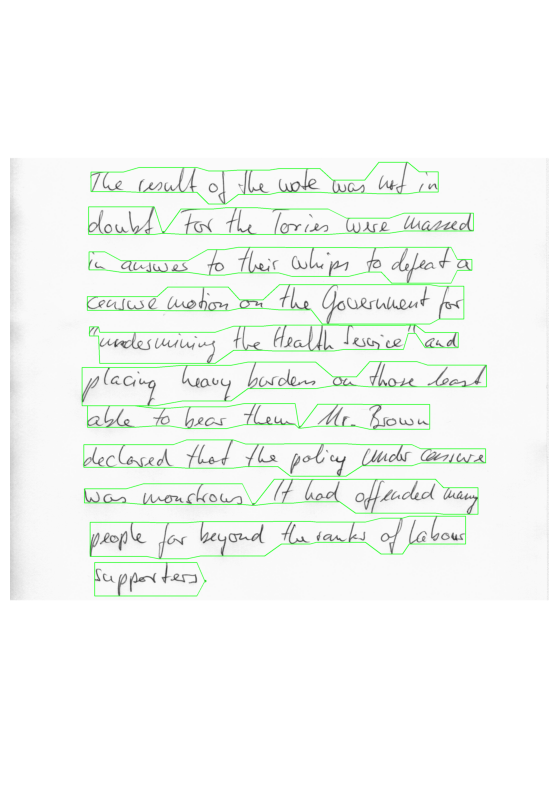

In [8]:
img_path = "iam_yolo_dataset/images/a01-091.png"
label_path = "iam_yolo_dataset/labels/a01-091.txt"

draw_yolo(img_path, label_path)

## Ohne Sortierung der Punkte:

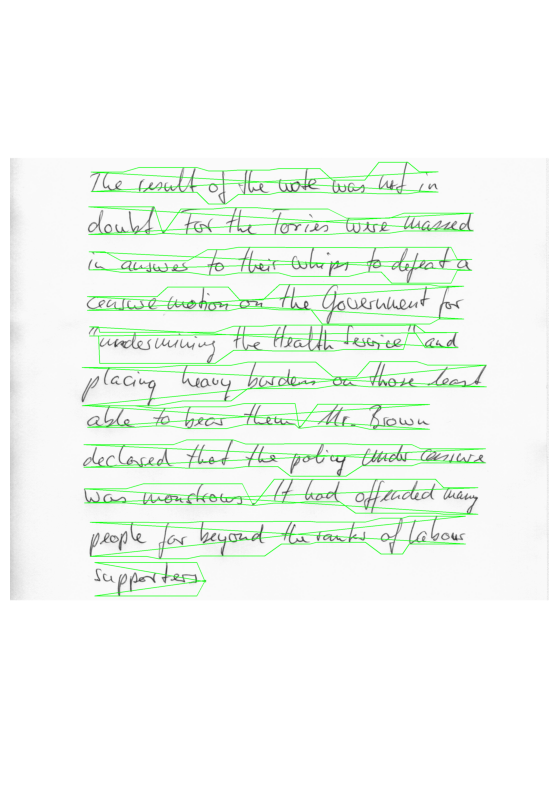

In [9]:
img_path = "iam_yolo_dataset/images/a01-091.png"
label_path = "labels_no_sort/a01-091.txt"

draw_yolo(img_path, label_path)

## Als Masken:

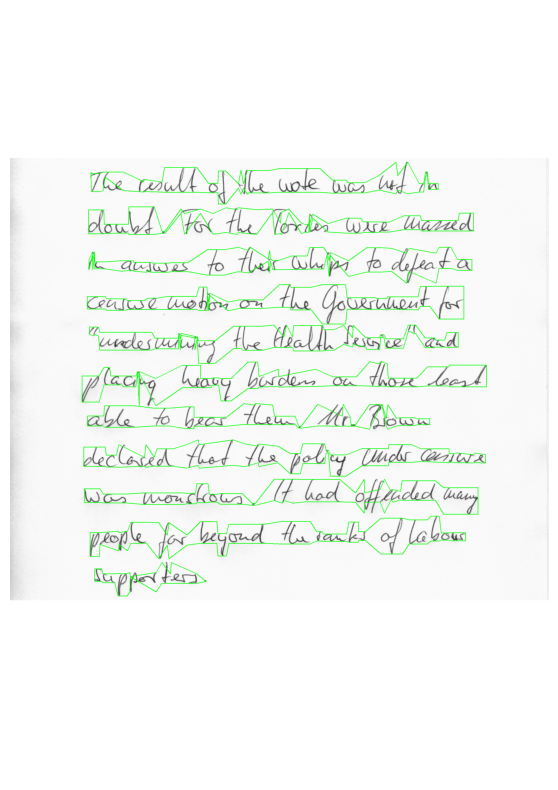

In [10]:
img_path = "iam_yolo_dataset/images/a01-091.png"
label_path = "mask_label/a01-091.txt"

draw_yolo(img_path, label_path)